# Імпорти

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, roc_curve, auc
import joblib

import warnings
warnings.filterwarnings("ignore")

# Завантаження даних

In [60]:
raw_df = pd.read_csv('train.csv', index_col=0) # оскільки в наборі даних є колонка id - варто одразу її зчитати як індекс датасета

In [61]:
raw_df.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
id,,,,,,,,,,,,,
0,15779985.0,Nwankwo,678.0,France,Male,29.0,4.0,0.00,3.0,1.0,0.0,180626.36,0.0
1,15650086.0,Ch'in,687.0,France,Female,34.0,1.0,0.00,2.0,0.0,1.0,63736.17,0.0
2,15733602.0,Thompson,682.0,France,Female,52.0,6.0,0.00,3.0,0.0,0.0,179655.87,1.0
3,15645794.0,Macleod,753.0,Germany,Male,44.0,6.0,83347.25,2.0,1.0,0.0,161407.48,0.0
4,15633840.0,Hsia,544.0,Germany,Female,55.0,0.0,107747.57,1.0,1.0,0.0,176580.86,1.0


In [63]:
raw_df.isnull().any()

,0
CustomerId,False
Surname,False
CreditScore,False
Geography,False
Gender,False
Age,False
Tenure,False
Balance,False
NumOfProducts,False
HasCrCard,False


In [64]:
raw_df.Exited.value_counts(normalize=True)

,proportion
Exited,
0.0,0.796533
1.0,0.203467


In [65]:
raw_df.nunique()

,0
CustomerId,6348
Surname,764
CreditScore,378
Geography,3
Gender,2
Age,56
Tenure,11
Balance,3395
NumOfProducts,4
HasCrCard,2


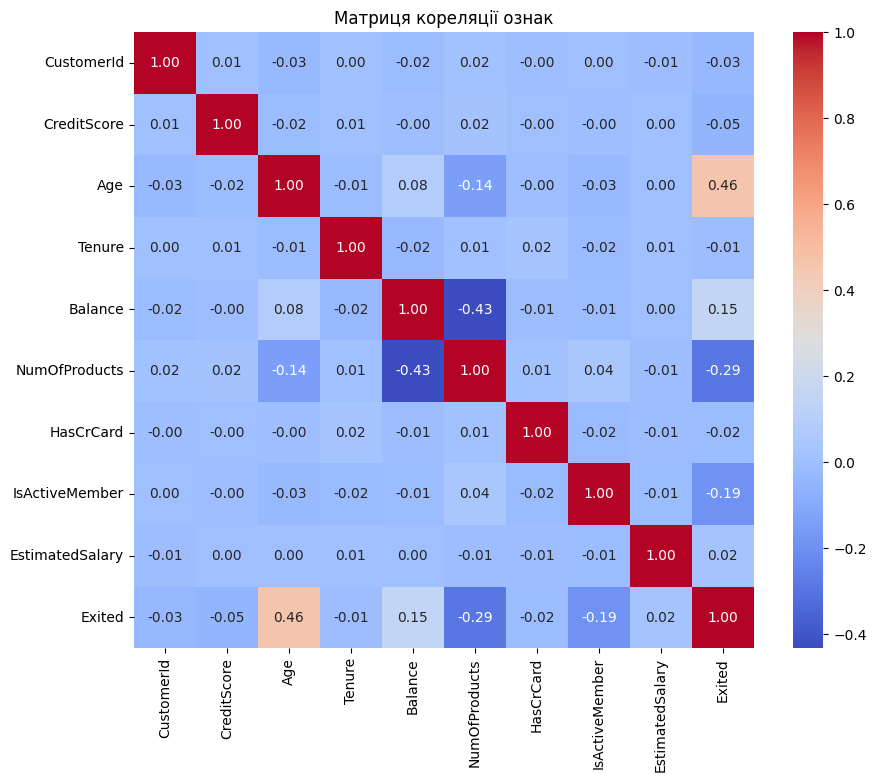

In [62]:
corr_matrix = raw_df.select_dtypes(include=['number']).corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Матриця кореляції ознак")
plt.show()

**Спостереження**

- Всі дані заповнені.
- Стовпець Exited розподілений 80:20, далі цю пропорцію потрібно зберегти при розбитті на тренувальний та валідаційний датасети.
- Для першої ітерації можна побудувати модель без CustomerId та Surname.
- З матриці кореляцій прослідковується найсильніший зв'язок між цільовою змінною та Age.

# Поділ на тренувальний та валідаційний датасети

In [68]:
train_df, val_df = train_test_split(raw_df, test_size=0.2, random_state=42, stratify=raw_df['Exited'])

In [69]:
train_df.Exited.value_counts(normalize=True)

,proportion
Exited,
0.0,0.7965
1.0,0.2035


In [70]:
val_df.Exited.value_counts(normalize=True)

,proportion
Exited,
0.0,0.796667
1.0,0.203333


In [71]:
print(f"Розмір тренувального датафрейму: {train_df.shape}")
print(f"Розмір валідаційного датафрейму: {val_df.shape}")

Розмір тренувального датафрейму: (12000, 13)
Розмір валідаційного датафрейму: (3000, 13)


# Створення незалежних змінних та цільової

In [72]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12000 entries, 7180 to 9360
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       12000 non-null  float64
 1   Surname          12000 non-null  object 
 2   CreditScore      12000 non-null  float64
 3   Geography        12000 non-null  object 
 4   Gender           12000 non-null  object 
 5   Age              12000 non-null  float64
 6   Tenure           12000 non-null  float64
 7   Balance          12000 non-null  float64
 8   NumOfProducts    12000 non-null  float64
 9   HasCrCard        12000 non-null  float64
 10  IsActiveMember   12000 non-null  float64
 11  EstimatedSalary  12000 non-null  float64
 12  Exited           12000 non-null  float64
dtypes: float64(10), object(3)
memory usage: 1.3+ MB


Модель будуватиму без двох колонок:
- `CustomerId` - додаватимуть тільки "шуму" моделі
- `Surname` - його потрібно детальніше вивчити, щоб закодувати.

In [73]:
input_cols = list(train_df.columns)[2:-1]
target_col = 'Exited'
train_inputs, train_targets = train_df[input_cols], train_df[target_col]
val_inputs, val_targets = val_df[input_cols], val_df[target_col]

print(f"Всього є {len(input_cols)} колонок, що сформують незалежні дані: {input_cols}.")
print(f"Цільова змінна: {target_col}.")

Всього є 10 колонок, що сформують незалежні дані: ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary'].
Цільова змінна: Exited.


In [77]:
numeric_cols = train_inputs.select_dtypes(include=np.number).columns.tolist()
print(f"Числові колонки: {numeric_cols}")

categorical_cols = train_inputs.select_dtypes(include='object').columns.tolist()
print(f"Категоріальні колонки: {categorical_cols}")

Числові колонки: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']
Категоріальні колонки: ['Geography', 'Gender']


# Масштабування числових та кодування категоріальних даних

In [78]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15000 entries, 0 to 14999
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       15000 non-null  float64
 1   Surname          15000 non-null  object 
 2   CreditScore      15000 non-null  float64
 3   Geography        15000 non-null  object 
 4   Gender           15000 non-null  object 
 5   Age              15000 non-null  float64
 6   Tenure           15000 non-null  float64
 7   Balance          15000 non-null  float64
 8   NumOfProducts    15000 non-null  float64
 9   HasCrCard        15000 non-null  float64
 10  IsActiveMember   15000 non-null  float64
 11  EstimatedSalary  15000 non-null  float64
 12  Exited           15000 non-null  float64
dtypes: float64(10), object(3)
memory usage: 1.6+ MB


In [79]:
train_inputs.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
id,,,,,,,,,,
7180,682.0,France,Male,30.0,1.0,131394.56,1.0,1.0,1.0,143952.24
10393,684.0,France,Female,39.0,2.0,178058.06,1.0,1.0,0.0,145518.31
80,705.0,Germany,Male,35.0,6.0,116320.68,2.0,1.0,0.0,174431.01
3365,669.0,Spain,Male,58.0,0.0,0.00,2.0,0.0,1.0,51565.98
12236,707.0,France,Male,21.0,3.0,0.00,2.0,1.0,1.0,148564.76


In [80]:
numeric_cols

['CreditScore',
 'Age',
 'Tenure',
 'Balance',
 'NumOfProducts',
 'HasCrCard',
 'IsActiveMember',
 'EstimatedSalary']

In [81]:
# Min max scaling
scaler = MinMaxScaler()
train_inputs[numeric_cols] = scaler.fit_transform(train_inputs[numeric_cols])
val_inputs[numeric_cols] = scaler.transform(val_inputs[numeric_cols])

# One hot encoding
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='if_binary')
encoder.fit(train_inputs[categorical_cols])
encoded_cols = list(encoder.get_feature_names_out(categorical_cols))
print(encoded_cols)
train_inputs[encoded_cols] = encoder.transform(train_inputs[categorical_cols])
val_inputs[encoded_cols] = encoder.transform(val_inputs[categorical_cols])

['Geography_France', 'Geography_Germany', 'Geography_Spain', 'Gender_Male']


In [82]:
pd.set_option('display.max_columns', None)

In [83]:
display(train_inputs[:5], val_inputs[:5])

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Male
id,,,,,,,,,,,,,,
7180,0.599045,France,Male,0.214286,0.1,0.626382,0.000000,1.0,1.0,0.719772,1.0,0.0,0.0,1.0
10393,0.603819,France,Female,0.375000,0.2,0.848836,0.000000,1.0,0.0,0.727603,1.0,0.0,0.0,0.0
80,0.653938,Germany,Male,0.303571,0.6,0.554522,0.333333,1.0,0.0,0.872180,0.0,1.0,0.0,1.0
3365,0.568019,Spain,Male,0.714286,0.0,0.000000,0.333333,0.0,1.0,0.257797,0.0,0.0,1.0,1.0
12236,0.658711,France,Male,0.053571,0.3,0.000000,0.333333,1.0,1.0,0.742837,1.0,0.0,0.0,1.0


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Male
id,,,,,,,,,,,,,,
6490,0.675418,Germany,Male,0.500000,0.1,0.551870,1.000000,1.0,1.0,0.364704,0.0,1.0,0.0,1.0
3646,0.386635,France,Male,0.410714,0.5,0.000000,0.333333,1.0,1.0,0.190942,1.0,0.0,0.0,1.0
5306,0.715990,France,Female,0.357143,0.2,0.000000,0.333333,0.0,1.0,0.584853,1.0,0.0,0.0,0.0
652,0.577566,France,Female,0.446429,0.4,0.742441,0.000000,0.0,1.0,0.558109,1.0,0.0,0.0,0.0
2627,0.589499,Spain,Female,0.214286,0.4,0.000000,0.333333,1.0,0.0,0.718420,0.0,0.0,1.0,0.0


# Збереження даних

In [84]:
train_inputs.to_parquet('train_inputs.parquet')
val_inputs.to_parquet('val_inputs.parquet')
pd.DataFrame(train_targets).to_parquet('train_targets.parquet')
pd.DataFrame(val_targets).to_parquet('val_targets.parquet')

# Навчання моделі

In [85]:
X_train = train_inputs[numeric_cols + encoded_cols]
X_val = val_inputs[numeric_cols + encoded_cols]

In [87]:
model = LogisticRegression(solver='liblinear')
model.fit(X_train, train_targets)

LogisticRegression(solver='liblinear')

In [91]:
model.coef_.round(2)

array([[-0.88,  8.45, -0.08, -1.1 , -3.94, -0.19, -1.25,  0.19, -1.03,
         0.54, -1.12, -0.86]])

In [92]:
model.intercept_

array([-1.60464126])

In [94]:
train_preds = model.predict(X_train)
train_preds[:5]

array([0., 0., 0., 0., 0.])

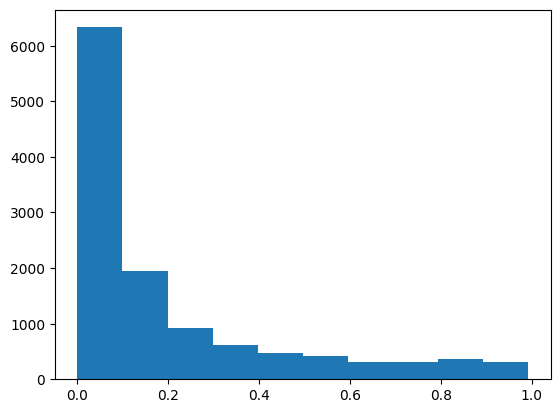

In [90]:
train_probs = model.predict_proba(X_train)

plt.hist(train_probs[:,1])
plt.show()

## Оцінка моделі: accuracy_score, Confusion matrix, ROC Curve, AUROC та F1 Score

In [95]:
# для тренувального набору
accuracy_score(train_targets, train_preds)

0.87425

In [96]:
# для валідаційного набору
val_preds = model.predict(X_val)
accuracy_score(val_targets, val_preds)

0.8716666666666667

Модель досягає точності 87,43% на навчальному наборі та 87,17% на валідаційному.

In [97]:
def get_metrics(model, inputs, targets, name=''):
    preds = model.predict(inputs)

    print(f"F1-score: {f1_score(targets, preds):.2f}")

    fpr, tpr, _ = roc_curve(targets, preds)
    roc_auc = auc(fpr, tpr)
    print(f"ROC AUC: {roc_auc:.2f}")

    cf = confusion_matrix(targets, preds, normalize='true')
    plt.figure()
    sns.heatmap(cf, annot=True)
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title('{} Confusion Matrix'.format(name));

F1-score: 0.64
ROC AUC: 0.75


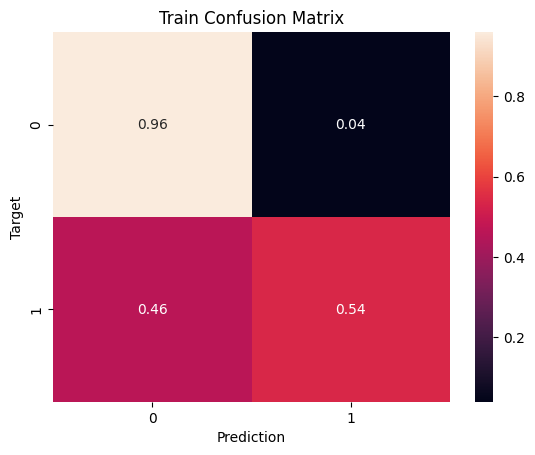

In [98]:
get_metrics(model, train_inputs[numeric_cols + encoded_cols], train_targets, 'Train')

F1-score: 0.64
ROC AUC: 0.76


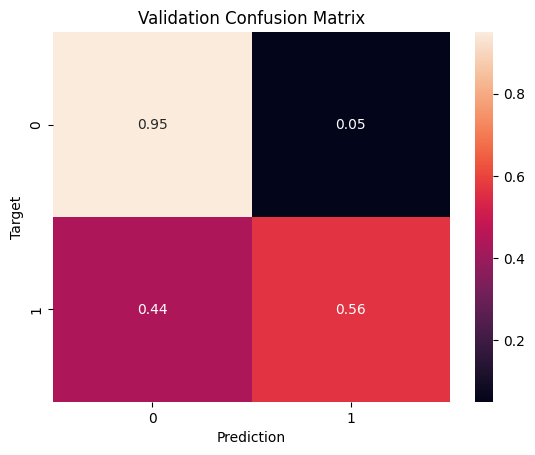

In [99]:
get_metrics(model, val_inputs[numeric_cols + encoded_cols], val_targets, 'Validation')

## Порівняння з моделлю, яка передбачає завжди мажоритарний клас

In [100]:
def all_no(inputs):
    return np.full(len(inputs), 0)

In [101]:
# all_no model
print(accuracy_score(train_targets, all_no(X_train)))
print(accuracy_score(val_targets, all_no(X_val)))

0.7965
0.7966666666666666


Модель ліпша за ту, яка кожному екземпляру каже, що він належить класу 0.

# Збереження моделі

In [103]:
objects_to_save = {
    'model': model,
    'scaler': scaler,
    'encoder': encoder,
    'input_cols': input_cols,
    'target_col': target_col,
    'numeric_cols': numeric_cols,
    'categorical_cols': categorical_cols,
    'encoded_cols': encoded_cols
}

joblib.dump(objects_to_save, 'log_reg.joblib')

['log_reg.joblib']

In [104]:
# функція робить підготовку даних і виводить ймовірності належності до класу 1 для кожного рядка в наданому наборі
def predict_raw_df(scaler, encoder, numeric_cols, categorical_cols, input_df: pd.DataFrame):
    input_df[numeric_cols] = scaler.transform(input_df[numeric_cols])
    input_df[encoded_cols] = encoder.transform(input_df[categorical_cols])
    X_input = input_df[numeric_cols + encoded_cols]
    prob = model.predict_proba(X_input)[:,1]
    return prob

In [106]:
predict_raw_df(scaler, encoder, numeric_cols, categorical_cols, raw_df[:5])

array([0.00653297, 0.03674711, 0.37092276, 0.37605273, 0.97579676])